# Telecom Customer Churn Analysis

This notebook explores churn patterns, trains and compares classification models, selects a churn-focused probability threshold, reviews model behavior, and exports the model used by the Streamlit app. Run cells from top to bottom.


## 1. Load and inspect the data

The notebook searches for `Customer_Churn.csv` in the project folder and then in the adjacent `DATASET` folder. The CSV is local and is not committed to this repository.


In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, classification_report,
                             confusion_matrix, precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_validate,
                                     cross_val_predict, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
candidate_paths = [Path("Customer_Churn.csv"), Path.cwd().parent.parent / "DATASET" / "Customer_Churn.csv"]
data_path = next((path for path in candidate_paths if path.is_file()), None)
if data_path is None:
    searched = "\n".join(str(path.resolve()) for path in candidate_paths)
    raise FileNotFoundError(f"Customer_Churn.csv was not found. Place it in the project or adjacent DATASET folder. Checked:\n{searched}")

df = pd.read_csv(data_path)
print(f"Loaded {data_path} with {df.shape[0]:,} rows and {df.shape[1]} columns.")
display(df.head())
df.info()
display(df.isna().sum().sort_values(ascending=False).head(10))


Loaded C:\Users\2024y\Documents\ML_ENGINEERING\DATASET\Customer_Churn.csv with 7,043 rows and 21 columns.
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    

   customerID  gender  SeniorCitizen  ... MonthlyCharges TotalCharges  Churn
0  7590-VHVEG  Female              0  ...          29.85        29.85     No
1  5575-GNVDE    Male              0  ...          56.95       1889.5     No
2  3668-QPYBK    Male              0  ...          53.85       108.15    Yes
3  7795-CFOCW    Male              0  ...          42.30      1840.75     No
4  9237-HQITU  Female              0  ...          70.70       151.65    Yes

[5 rows x 21 columns]

customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64

### Section summary

The data is loaded from a portable project-relative location. The initial checks report its dimensions, data types, sample rows, and missing-value counts.


## 2. Clean the data

`TotalCharges` can contain blank strings, making it appear as text. Convert it to numeric, replace blank totals with zero, and validate the target labels before modeling.


In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

if "Churn" not in df.columns:
    raise KeyError("The dataset must contain a 'Churn' target column.")
if not set(df["Churn"].dropna().unique()).issubset({"Yes", "No"}):
    raise ValueError("Expected Churn values to be 'Yes' or 'No'.")

print("Missing TotalCharges after cleaning:", int(df["TotalCharges"].isna().sum()))
display(df["TotalCharges"].describe())

Missing TotalCharges after cleaning: 0


count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

### Section summary

`TotalCharges` is numeric with blank entries treated as zero. The target column and its expected `Yes`/`No` values are checked before training.


## 3. Exploratory data analysis

Compare churn prevalence and churn rates across tenure, contract, monthly charges, internet service, and payment method. These are descriptive patterns, not proof of causation.


Overall churn rate: 26.5%


Churn
No     5174
Yes    1869
Name: Customer count, dtype: int64

Churn              No    Yes
Contract                    
Month-to-month  0.573  0.427
One year        0.887  0.113
Two year        0.972  0.028

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0           64.43       1679.52
Yes      10.0           79.65        703.55

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  0.833  0.167
Credit card (automatic)    0.848  0.152
Electronic check           0.547  0.453
Mailed check               0.809  0.191

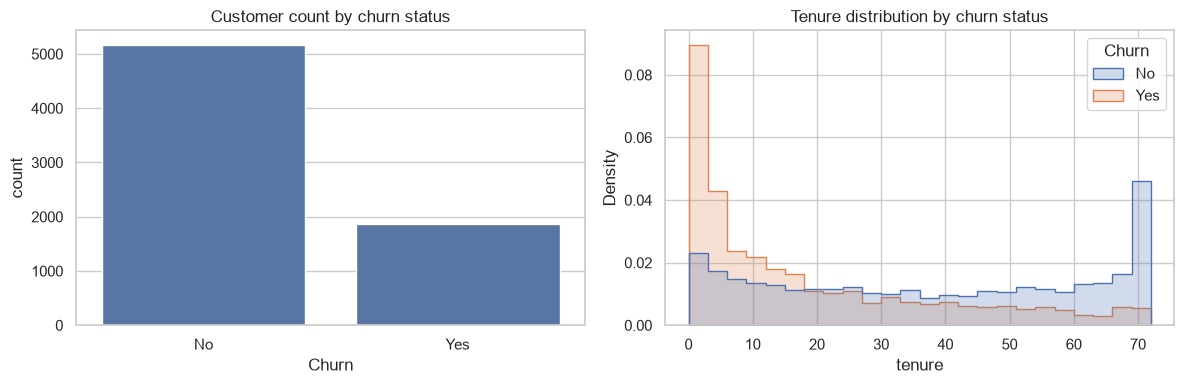

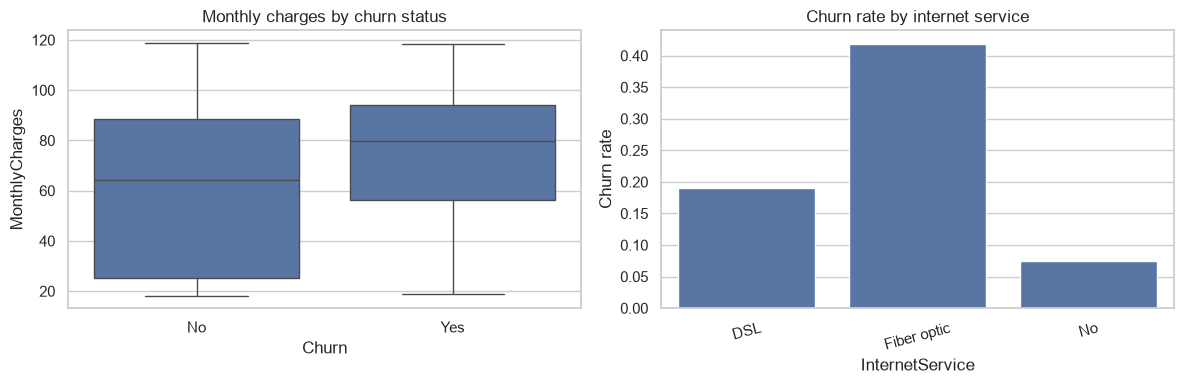

In [8]:
churn_counts = df["Churn"].value_counts().reindex(["No", "Yes"], fill_value=0)
print(f"Overall churn rate: {df['Churn'].eq('Yes').mean():.1%}")
display(churn_counts.rename("Customer count"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="Churn", order=["No", "Yes"], ax=axes[0])
axes[0].set_title("Customer count by churn status")
sns.histplot(data=df, x="tenure", hue="Churn", bins=24, element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Tenure distribution by churn status")
plt.tight_layout()
plt.show()

display(pd.crosstab(df["Contract"], df["Churn"], normalize="index").round(3))
display(df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].median().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", order=["No", "Yes"], ax=axes[0])
axes[0].set_title("Monthly charges by churn status")
service_rates = df.assign(ChurnFlag=df["Churn"].eq("Yes").astype(float)).groupby("InternetService", as_index=False)["ChurnFlag"].mean()
sns.barplot(data=service_rates, x="InternetService", y="ChurnFlag", ax=axes[1])
axes[1].set_title("Churn rate by internet service")
axes[1].set_ylabel("Churn rate")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

display(pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index").round(3))

### Section summary

Churn is the minority outcome (about 26.5% in the supplied dataset). The plots and tables show sample differences in tenure, contracts, monthly charges, internet service, and payment method. These patterns help guide modeling but do not explain individual causes.


## 4. Split data and define preprocessing

Remove the identifier and target from the predictors. Stratify the holdout split so train and test retain similar churn proportions. Scale continuous values and one-hot encode categories inside a pipeline to avoid preprocessing leakage.


In [11]:
X = df.drop(columns=["customerID", "Churn"], errors="ignore")
y = df["Churn"].map({"No": 0, "Yes": 1}).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
missing_numeric = set(numeric_features) - set(X_train.columns)
if missing_numeric:
    raise KeyError(f"Required numeric features are missing: {sorted(missing_numeric)}")
categorical_features = [column for column in X_train.columns if column not in numeric_features]
preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

print(f"Training rows: {len(X_train):,}; test rows: {len(X_test):,}")
print(f"Numeric features: {len(numeric_features)}; categorical features: {len(categorical_features)}")

Training rows: 5,634; test rows: 1,409
Numeric features: 3; categorical features: 16


### Section summary

The stratified holdout is kept separate from training. Each model pipeline will learn preprocessing from its training data and safely ignore unseen categories at prediction time.


## 5. Cross-validated model selection and tuning
Compare default logistic regression, decision tree, and random forest with stratified cross-validation on training data. Tune each model with GridSearchCV using average precision, then compare tuned and default holdout results after selection.


In [14]:
# Compare default models with the same stratified folds using training data only.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "precision": "precision", "recall": "recall"}
models = {
    "Logistic regression": Pipeline([("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=1000, random_state=42))]),
    "Decision tree": Pipeline([("preprocessor", preprocessor), ("model", DecisionTreeClassifier(random_state=42))]),
    "Random forest": Pipeline([("preprocessor", preprocessor), ("model", RandomForestClassifier(random_state=42))]),
}

default_cv_rows = []
for name, candidate in models.items():
    scores = cross_validate(candidate, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    default_cv_rows.append({"Model": name, **{metric: scores[f"test_{metric}"].mean() for metric in scoring}})
default_cv = pd.DataFrame(default_cv_rows).set_index("Model").sort_values("pr_auc", ascending=False)
print("Default model performance on five stratified folds of training data:")
display(default_cv.round(3))

# Search compact, model-specific grids. Average precision prioritizes ranking churners.
param_grids = {
    "Logistic regression": {"model__C": [0.1, 1, 10]},
    "Decision tree": {"model__max_depth": [None, 5, 10], "model__min_samples_leaf": [1, 5]},
    "Random forest": {"model__n_estimators": [100, 200], "model__max_depth": [None, 10], "model__min_samples_leaf": [1, 5]},
}
searches = {}
for name, candidate in models.items():
    search = GridSearchCV(candidate, param_grids[name], scoring="average_precision", cv=cv, n_jobs=-1, refit=True)
    search.fit(X_train, y_train)
    searches[name] = search
    print(f"{name}: best CV PR-AUC={search.best_score_:.3f}; params={search.best_params_}")

# Compare default and tuned pipelines on the untouched holdout at the conventional 0.5 cutoff.
default_holdout_rows, tuned_holdout_rows = [], []
for name, candidate in models.items():
    candidate.fit(X_train, y_train)
    for label, fitted, rows in [("Default", candidate, default_holdout_rows), ("Tuned", searches[name].best_estimator_, tuned_holdout_rows)]:
        prob = fitted.predict_proba(X_test)[:, 1]
        pred = (prob >= 0.5).astype(int)
        rows.append({"Model": name, "Accuracy": accuracy_score(y_test, pred),
                     "Precision": precision_score(y_test, pred, zero_division=0),
                     "Recall": recall_score(y_test, pred, zero_division=0),
                     "ROC-AUC": roc_auc_score(y_test, prob), "PR-AUC": average_precision_score(y_test, prob)})
default_holdout = pd.DataFrame(default_holdout_rows).set_index("Model")
tuned_holdout = pd.DataFrame(tuned_holdout_rows).set_index("Model")
print("Default holdout results (threshold 0.5):")
display(default_holdout.round(3))
print("Tuned holdout results (threshold 0.5):")
display(tuned_holdout.round(3))

# Select the highest training-fold average precision; use its tuned estimator for remaining analysis.
selected_name = max(searches, key=lambda name: searches[name].best_score_)
pipe = searches[selected_name].best_estimator_
pipe.fit(X_train, y_train)
print(f"Selected by mean five-fold training PR-AUC: {selected_name}")


Default model performance on five stratified folds of training data:
Logistic regression: best CV PR-AUC=0.661; params={'model__C': 1}
Decision tree: best CV PR-AUC=0.615; params={'model__max_depth': 5, 'model__min_samples_leaf': 5}
Random forest: best CV PR-AUC=0.661; params={'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Default holdout results (threshold 0.5):
Tuned holdout results (threshold 0.5):
Selected by mean five-fold training PR-AUC: Logistic regression


                     roc_auc  pr_auc  precision  recall
Model                                                  
Logistic regression    0.846   0.661      0.652   0.544
Random forest          0.818   0.606      0.627   0.476
Decision tree          0.658   0.381      0.496   0.500

                     Accuracy  Precision  Recall  ROC-AUC  PR-AUC
Model                                                            
Logistic regression     0.806      0.657   0.559    0.842   0.634
Decision tree           0.718      0.469   0.479    0.641   0.363
Random forest           0.784      0.612   0.505    0.818   0.600

                     Accuracy  Precision  Recall  ROC-AUC  PR-AUC
Model                                                            
Logistic regression     0.806      0.657   0.559    0.842   0.634
Decision tree           0.798      0.635   0.567    0.827   0.621
Random forest           0.805      0.669   0.524    0.843   0.659

### Section summary
The three default pipelines are compared with five stratified folds on training data. Grid search tunes model-specific parameters using average precision, then tuned and default estimators are compared on the untouched holdout at threshold 0.5. The highest mean training-fold PR-AUC determines which tuned pipeline proceeds.


## 6. Threshold selection and probability calibration
Use out-of-fold training probabilities to inspect the full precision-recall curve and the 0.4 operating point. Check probability calibration on training folds and fit sigmoid calibration only when the ten-bin gap exceeds 0.05. Evaluate the chosen threshold on the held-out test set after those decisions are fixed.


Out-of-fold calibration gap (10 bins): 0.011
Calibration gap was at most 0.05; retained the original probability estimates.
At 0.4 on training out-of-fold scores: precision=0.594, recall=0.664.
              precision    recall  f1-score   support

    No churn       0.87      0.82      0.84      1035
       Churn       0.57      0.67      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409

Holdout ROC-AUC: 0.842; PR-AUC (average precision): 0.634


           Accuracy  Precision  Recall
Threshold                             
0.3           0.749      0.519   0.754
0.4           0.777      0.568   0.668
0.5           0.806      0.657   0.559

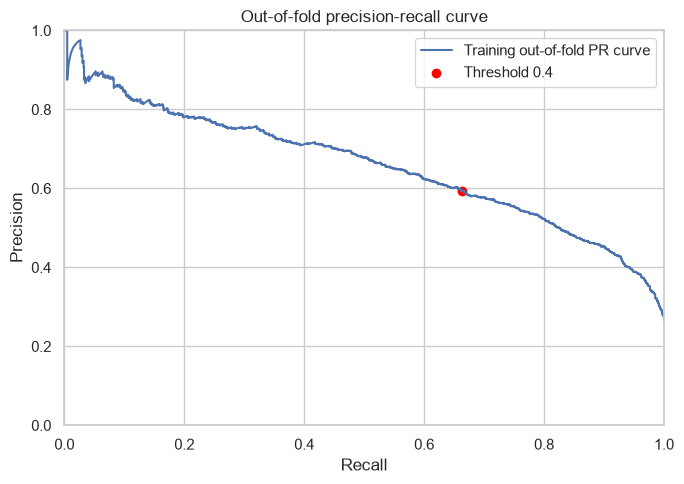

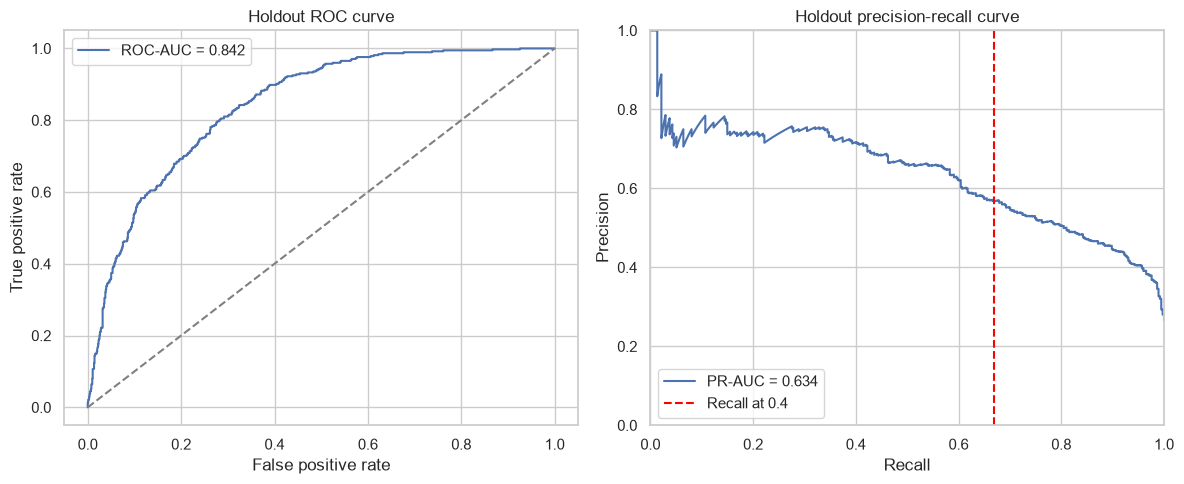

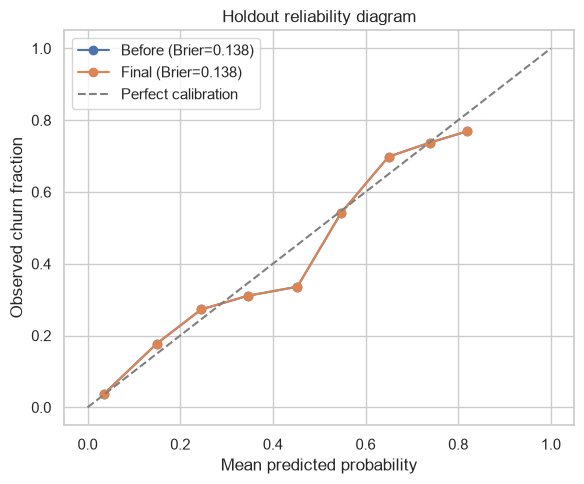

In [17]:
# Use out-of-fold training probabilities to inspect the precision-recall trade-off without using the holdout.
oof_raw_probability = cross_val_predict(pipe, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
oof_precision, oof_recall, oof_thresholds = precision_recall_curve(y_train, oof_raw_probability)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(oof_recall, oof_precision, label="Training out-of-fold PR curve")
ax.scatter([recall_score(y_train, oof_raw_probability >= 0.4)],
           [precision_score(y_train, oof_raw_probability >= 0.4, zero_division=0)],
           color="red", label="Threshold 0.4")
ax.set(title="Out-of-fold precision-recall curve", xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1))
ax.legend()
plt.tight_layout()
plt.show()

# Assess calibration on training-fold predictions. Apply sigmoid calibration only when mean bin error is above 0.05.
def calibration_gap(y_true, probability, bins=10):
    # Compute all bins explicitly so empty bins do not misalign the arrays.
    bin_ids = np.minimum((np.asarray(probability) * bins).astype(int), bins - 1)
    errors, counts = [], []
    y_array = np.asarray(y_true)
    for bin_id in range(bins):
        in_bin = bin_ids == bin_id
        if in_bin.any():
            errors.append(abs(y_array[in_bin].mean() - np.asarray(probability)[in_bin].mean()))
            counts.append(int(in_bin.sum()))
    return np.average(errors, weights=counts) if counts else 0.0

raw_calibration_gap = calibration_gap(y_train, oof_raw_probability)
print(f"Out-of-fold calibration gap (10 bins): {raw_calibration_gap:.3f}")
calibrated = raw_calibration_gap > 0.05
if calibrated:
    calibration_template = CalibratedClassifierCV(estimator=pipe, method="sigmoid", cv=cv)
    # Nested folds keep each probability out of the estimator's fitting fold.
    oof_probability = cross_val_predict(calibration_template, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    final_model = calibration_template.fit(X_train, y_train)
    print("Applied sigmoid calibration because the out-of-fold bin error exceeded 0.05.")
else:
    oof_probability = oof_raw_probability
    final_model = pipe
    print("Calibration gap was at most 0.05; retained the original probability estimates.")

# The 0.4 cutoff is marked against the full training PR curve for a visible recall/precision trade-off.
precision_at_04 = precision_score(y_train, oof_probability >= 0.4, zero_division=0)
recall_at_04 = recall_score(y_train, oof_probability >= 0.4, zero_division=0)
print(f"At 0.4 on training out-of-fold scores: precision={precision_at_04:.3f}, recall={recall_at_04:.3f}.")
CHURN_THRESHOLD = 0.4
y_probability = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_probability >= CHURN_THRESHOLD).astype(int)
threshold_rows = []
for threshold in [0.3, 0.4, 0.5]:
    prediction = (y_probability >= threshold).astype(int)
    threshold_rows.append({"Threshold": threshold, "Accuracy": accuracy_score(y_test, prediction),
                           "Precision": precision_score(y_test, prediction, zero_division=0),
                           "Recall": recall_score(y_test, prediction, zero_division=0)})
threshold_results = pd.DataFrame(threshold_rows).set_index("Threshold")
display(threshold_results.round(3))
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"], zero_division=0))

# Evaluate ranking quality on the holdout at the selected model's probability output.
holdout_roc_auc = roc_auc_score(y_test, y_probability)
holdout_pr_auc = average_precision_score(y_test, y_probability)
fpr, tpr, _ = roc_curve(y_test, y_probability)
pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_probability)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {holdout_roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set(title="Holdout ROC curve", xlabel="False positive rate", ylabel="True positive rate")
axes[0].legend()
axes[1].plot(pr_recall, pr_precision, label=f"PR-AUC = {holdout_pr_auc:.3f}")
axes[1].axvline(recall_score(y_test, y_pred), linestyle="--", color="red", label="Recall at 0.4")
axes[1].set(title="Holdout precision-recall curve", xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1))
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"Holdout ROC-AUC: {holdout_roc_auc:.3f}; PR-AUC (average precision): {holdout_pr_auc:.3f}")

# Show reliability and Brier score before and after any calibration.
from sklearn.metrics import brier_score_loss
raw_holdout_probability = pipe.predict_proba(X_test)[:, 1]
raw_brier = brier_score_loss(y_test, raw_holdout_probability)
final_brier = brier_score_loss(y_test, y_probability)
fig, ax = plt.subplots(figsize=(6, 5))
for probability, label in [(raw_holdout_probability, f"Before (Brier={raw_brier:.3f}"), (y_probability, f"Final (Brier={final_brier:.3f}")]:
    observed, predicted = calibration_curve(y_test, probability, n_bins=10, strategy="uniform")
    ax.plot(predicted, observed, marker="o", label=label + ")")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set(title="Holdout reliability diagram", xlabel="Mean predicted probability", ylabel="Observed churn fraction")
ax.legend()
plt.tight_layout()
plt.show()


### Section summary
The full precision-recall curve uses out-of-fold training probabilities, and the 0.4 point shows the resulting precision and recall trade-off. Calibration is checked on the same training-only predictions and sigmoid calibration is fitted only when the ten-bin gap exceeds 0.05. Holdout metrics are reported after these choices are fixed.


## 7. Review errors and segment performance
Inspect the confusion matrix, false negatives, and their tenure/charge profile. Report false-negative rates among actual churners by contract type and internet service, and show logistic coefficients when applicable.


False negatives at threshold 0.4: 124
Features most associated with a higher churn score:
Features most associated with a lower churn score:


       tenure  MonthlyCharges  TotalCharges
count  124.00          124.00        124.00
mean    27.95           63.78       2340.26
std     23.78           30.46       2447.95
min      1.00           18.95         19.30
25%      4.00           45.79        142.25
50%     24.00           59.70       1521.12
75%     49.25           94.61       3992.60
max     72.00          115.65       7968.85

           Segment        Category  ...  False negatives  False-negative rate
0         Contract  Month-to-month  ...               83                0.252
1         Contract        One year  ...               32                0.889
2         Contract        Two year  ...                9                1.000
3  InternetService             DSL  ...               53                0.546
4  InternetService     Fiber optic  ...               46                0.183
5  InternetService              No  ...               25                1.000

[6 rows x 5 columns]

                                       Feature  Coefficient
0     categorical__InternetService_Fiber optic        0.648
1         categorical__Contract_Month-to-month        0.586
2                        numeric__TotalCharges        0.533
3             categorical__StreamingMovies_Yes        0.212
4                 categorical__StreamingTV_Yes        0.212
5  categorical__PaymentMethod_Electronic check        0.206
6               categorical__OnlineSecurity_No        0.166
7                  categorical__TechSupport_No        0.141
8               categorical__MultipleLines_Yes        0.113
9            categorical__PaperlessBilling_Yes        0.042

                                             Feature  Coefficient
0                                    numeric__tenure       -1.255
1                     categorical__Contract_Two year       -0.759
2                   categorical__InternetService_DSL       -0.644
3                            numeric__MonthlyCharges       -0.601
4                   categorical__PaperlessBilling_No       -0.331
5                    categorical__InternetService_No       -0.293
6    categorical__OnlineSecurity_No internet service       -0.293
7      categorical__OnlineBackup_No internet service       -0.293
8  categorical__DeviceProtection_No internet service       -0.293
9       categorical__TechSupport_No internet service       -0.293

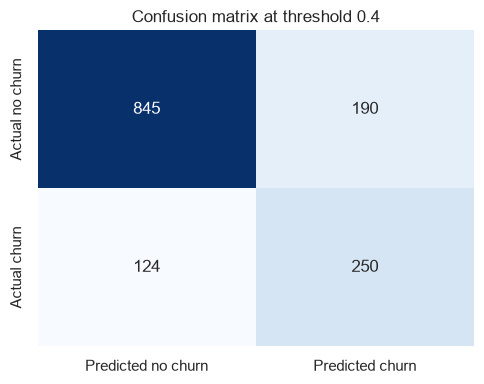

In [20]:
matrix = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted no churn", "Predicted churn"],
            yticklabels=["Actual no churn", "Actual churn"], ax=ax)
ax.set_title(f"Confusion matrix at threshold {CHURN_THRESHOLD:.1f}")
plt.tight_layout()
plt.show()

false_negatives = X_test.loc[(y_test == 1) & (y_pred == 0)]
print(f"False negatives at threshold {CHURN_THRESHOLD:.1f}: {len(false_negatives)}")
display(false_negatives[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2))

# Report the share of actual churners missed within each existing categorical segment.
segment_rows = []
for segment in ["Contract", "InternetService"]:
    for value, index in X_test.groupby(segment, dropna=False).groups.items():
        churner_index = [i for i in index if y_test.loc[i] == 1]
        if churner_index:
            missed = sum(y_pred[np.flatnonzero(y_test.index.isin(churner_index))] == 0)
            segment_rows.append({"Segment": segment, "Category": value, "Actual churners": len(churner_index),
                                 "False negatives": missed, "False-negative rate": missed / len(churner_index)})
segment_errors = pd.DataFrame(segment_rows)
display(segment_errors.round(3))

if selected_name == "Logistic regression":
    feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()
    coefficients = pipe.named_steps["model"].coef_[0]
    coefficient_table = pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients})
    print("Features most associated with a higher churn score:")
    display(coefficient_table.nlargest(10, "Coefficient").reset_index(drop=True).round(3))
    print("Features most associated with a lower churn score:")
    display(coefficient_table.nsmallest(10, "Coefficient").reset_index(drop=True).round(3))
else:
    print(f"Coefficient display is specific to logistic regression; selected model: {selected_name}.")


### Section summary
The confusion matrix and numeric false-negative profile describe holdout errors at threshold 0.4. Contract and internet-service tables report false-negative counts and rates among actual churners in each segment. Logistic-regression coefficients are shown when logistic regression is selected.


## 8. Explain predictions with LIME and SHAP

LIME explains one selected customer by making small feature changes and observing how the model score responds. SHAP assigns additive contributions to features; the summary plot compares their influence across test customers, and the waterfall plot explains one customer. Both methods use the same transformed features the model receives.


                                    Feature condition  LIME contribution
0                              numeric__tenure > 0.92          -0.259245
1                        numeric__TotalCharges > 0.67           0.162911
2                      numeric__MonthlyCharges > 0.83          -0.122894
3               categorical__Contract_Two year > 0.00          -0.092079
4            categorical__InternetService_DSL <= 0.00           0.087086
5   0.00 < categorical__InternetService_Fiber opti...           0.085147
6        categorical__Contract_Month-to-month <= 0.00          -0.082135
7   categorical__OnlineSecurity_No internet servic...           0.050896
8   categorical__StreamingTV_No internet service <...           0.049932
9   categorical__StreamingMovies_No internet servi...           0.048720
10           categorical__PaperlessBilling_No <= 0.00           0.047533
11  categorical__DeviceProtection_No internet serv...           0.045641

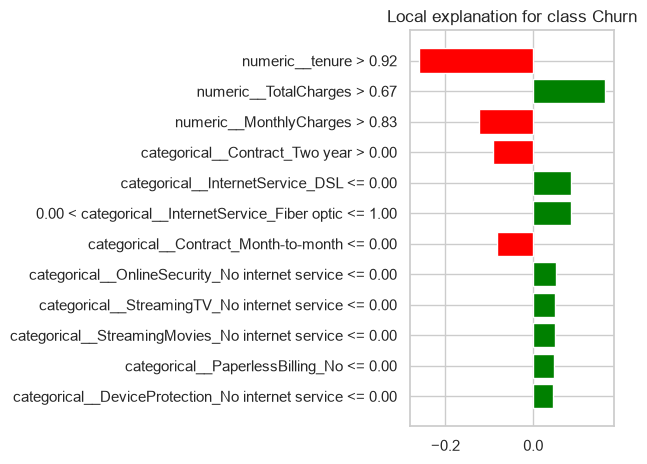

In [23]:

# Use the selected fitted pipeline's preprocessing and classifier for local explanations.
explain_preprocessor = pipe.named_steps["preprocessor"]
explain_model = pipe.named_steps["model"]
explain_feature_names = explain_preprocessor.get_feature_names_out()
def make_dense(feature_matrix):
    return feature_matrix.toarray() if hasattr(feature_matrix, "toarray") else np.asarray(feature_matrix)
X_train_explain = make_dense(explain_preprocessor.transform(X_train))
X_test_explain = make_dense(explain_preprocessor.transform(X_test))
lime_explainer = LimeTabularExplainer(X_train_explain, feature_names=list(explain_feature_names),
    class_names=["No churn", "Churn"], mode="classification", discretize_continuous=True, random_state=42)
lime_explanation = lime_explainer.explain_instance(X_test_explain[0], explain_model.predict_proba,
    num_features=min(12, len(explain_feature_names)))
display(pd.DataFrame(lime_explanation.as_list(), columns=["Feature condition", "LIME contribution"]))
lime_figure = lime_explanation.as_pyplot_figure()
lime_figure.tight_layout()
plt.show()


  plt.show()
  plt.show()
  plt.show()


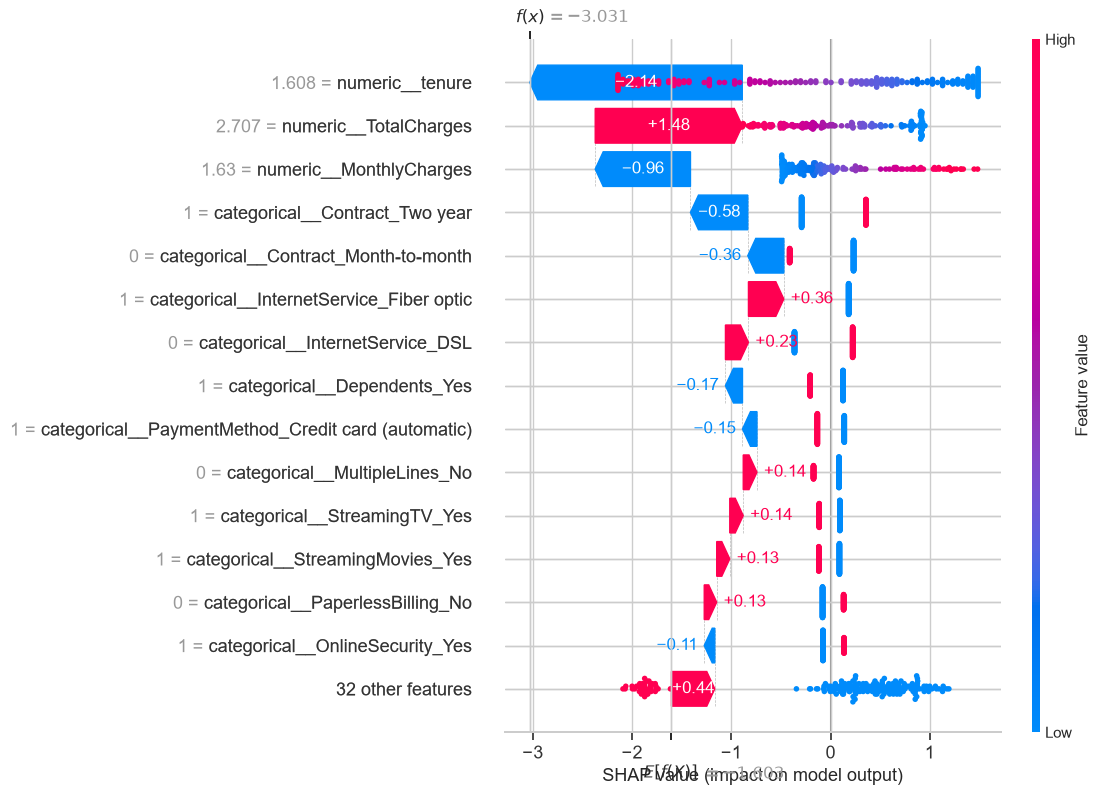

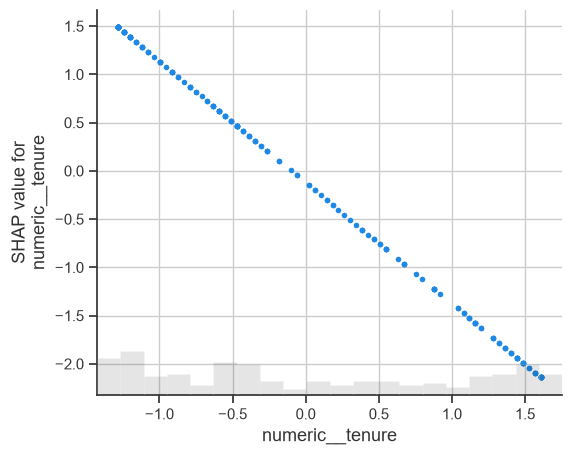

In [24]:

shap_background = pd.DataFrame(X_train_explain[:min(100, len(X_train_explain))], columns=explain_feature_names)
shap_test = pd.DataFrame(X_test_explain[:min(200, len(X_test_explain))], columns=explain_feature_names)
if isinstance(explain_model, LogisticRegression):
    shap_explainer = shap.LinearExplainer(explain_model, shap_background)
else:
    shap_explainer = shap.TreeExplainer(explain_model)
shap_values = shap_explainer(shap_test)
shap.plots.beeswarm(shap_values, max_display=15)
shap.plots.waterfall(shap_values[0], max_display=15)
if "numeric__tenure" in shap_values.feature_names:
    shap.plots.scatter(shap_values[:, "numeric__tenure"])


### Section summary

LIME gives a local, model-agnostic explanation for one customer. SHAP gives additive feature contributions, with a beeswarm view across the test sample and a waterfall view for one customer. Both operate on the pipeline's transformed inputs, so the encoded feature names line up with the model. Explanations describe model behavior; they do not establish causality.


## 9. Export the model for Streamlit
Export the selected pipeline, including calibration when applied. The Streamlit app applies the 0.4 decision threshold.


In [27]:
# Refresh the checked-in artifact only when the selected estimator family or its parameters changed.
model_path = Path("churn_model.pkl")
should_save = not model_path.is_file() or calibrated
if model_path.is_file() and not calibrated:
    existing_model = joblib.load(model_path)
    existing_estimator = existing_model.named_steps["model"] if hasattr(existing_model, "named_steps") else existing_model
    selected_estimator = final_model.named_steps["model"]
    should_save = type(existing_estimator) is not type(selected_estimator) or existing_estimator.get_params(deep=False) != selected_estimator.get_params(deep=False)
if should_save:
    joblib.dump(final_model, model_path)
    print(f"Saved tuned fitted model to {model_path.resolve()} because selected family or parameters changed.")
else:
    print("Selected model family and parameters match the existing artifact; no artifact refresh was needed.")


Selected model family and parameters match the existing artifact; no artifact refresh was needed.


### Section summary
The exported estimator includes preprocessing and the selected classifier, with calibration when the training-only calibration check required it. The app can load this artifact without rebuilding preprocessing separately.


## 10. Final results and project summary
Review the measured holdout results and summarize the workflow. Performance values are generated from the local CSV when the notebook runs.


In [30]:
final_results = pd.Series({
    "Selected model": selected_name,
    "Best parameters": str(searches[selected_name].best_params_),
    "Decision threshold": CHURN_THRESHOLD,
    "Calibration applied": calibrated,
    "Holdout accuracy": accuracy_score(y_test, y_pred),
    "Holdout precision": precision_score(y_test, y_pred, zero_division=0),
    "Holdout recall": recall_score(y_test, y_pred, zero_division=0),
    "Holdout ROC-AUC": holdout_roc_auc,
    "Holdout PR-AUC": holdout_pr_auc,
    "True positives": int(matrix[1, 1]),
    "False negatives": int(matrix[1, 0]),
    "False positives": int(matrix[0, 1]),
})
display(final_results.to_frame("Result"))


                                  Result
Selected model       Logistic regression
Best parameters          {'model__C': 1}
Decision threshold                   0.4
Calibration applied                False
Holdout accuracy                0.777147
Holdout precision               0.568182
Holdout recall                  0.668449
Holdout ROC-AUC                 0.842034
Holdout PR-AUC                  0.633702
True positives                       250
False negatives                      124
False positives                      190

### Recorded holdout results
The exact results are generated above from the local CSV each time the notebook runs. No numbers are hard-coded here because the dataset is not stored in the repository and library versions can affect fitted results.


### Section summary
The notebook loaded and cleaned the data, explored churn patterns, compared three classifiers with stratified cross-validation, tuned model parameters, selected a model using training-fold PR-AUC, assessed calibration, and evaluated a fixed 0.4 threshold on the holdout. ROC-AUC, PR-AUC, reliability, segment false-negative rates, LIME, and SHAP provide complementary views of performance and model behavior. Results depend on the local data and software versions.
